The EDA gave us a clear picture of the data. Now we turn that into something a model can actually learn from. The goal here is to build features that capture how each customer behaves, not just how much they've spent, but how recently, how often, and how deep their product engagement goes.

In [1]:
# import libraries
import requests, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

In [3]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### **Data Cleaning**

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Shape of data before cleaning:", df.shape)

Shape of data before cleaning: (525461, 8)


In [5]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [6]:
df = df[df["Quantity"] > 0]

In [7]:
df = df[df["Price"] > 0]

In [8]:
df = df.dropna(subset=["Customer ID"])

In [9]:
df = df.drop_duplicates()

In [10]:
df["Customer ID"] = df["Customer ID"].astype(int)

In [11]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [12]:
print("Shape of data after cleaning:", df.shape)
print("Unique customers:", df["Customer ID"].nunique())

Shape of data after cleaning: (400916, 9)
Unique customers: 4312


After cleaning the data, we're working with 400,916 transactions across 4,312 customers.

### **Prediction Window**

In [13]:
# Date range
print("Date range:", df["InvoiceDate"].min().date(), "to", df["InvoiceDate"].max().date())

Date range: 2009-12-01 to 2010-12-09


In [14]:
# Cutoff date
observation_end = pd.Timestamp('2010-08-31')
prediction_end  = pd.Timestamp('2010-12-09')

obs_df  = df[df['InvoiceDate'] <= observation_end].copy()
pred_df = df[(df['InvoiceDate'] > observation_end) &
             (df['InvoiceDate'] <= prediction_end)].copy()

In [15]:
print("Observation window:", obs_df["InvoiceDate"].min().date(), "to", obs_df["InvoiceDate"].max().date())
print("Prediction window:", pred_df["InvoiceDate"].min().date(), "to", pred_df["InvoiceDate"].max().date())
print("Customers in observation:", obs_df["Customer ID"].nunique())
print("Customers in prediction:", pred_df["Customer ID"].nunique())

Observation window: 2009-12-01 to 2010-08-29
Prediction window: 2010-08-31 to 2010-12-08
Customers in observation: 3313
Customers in prediction: 2981


The data runs from December 2009 to December 2010. We split it into two windows: everything up to August 31st is the observation period, where we build features from. September through December is the prediction window, where we measure actual revenue to use as the target variable. 3,313 customers appear in the observation window, 2,981 in the prediction window. Not every customer bought in both periods, and it is true in real world.

### **Target Variable**

In [16]:
# Total revenue per customer in the prediction window
ltv_target = (pred_df.groupby("Customer ID")["Revenue"]
              .sum()
              .reset_index()
              .rename(columns={"Revenue":"ltv_3m"}))
ltv_target.head()

,Customer ID,ltv_3m
0,12347,1323.32
1,12348,222.16
2,12349,1402.62
3,12351,300.93
4,12352,343.80


In [17]:
# All observation customers
all_customers = obs_df[["Customer ID"]].drop_duplicates()

In [18]:
# Merge
target = all_customers.merge(ltv_target, on="Customer ID", how="left")
target["ltv_3m"] = target["ltv_3m"].fillna(0)
target.head()

,Customer ID,ltv_3m
0,13085,0.00
1,13078,6055.27
2,15362,302.33
3,18102,81046.32
4,12682,3054.81


In [19]:
print("Total customers in target table:", len(target))
print("Customers with ltv_3m = 0:", (target["ltv_3m"] == 0).sum())
print("Customer with ltv_3m > 0:", (target["ltv_3m"] > 0).sum())

Total customers in target table: 3313
Customers with ltv_3m = 0: 1328
Customer with ltv_3m > 0: 1985


We have 3,313 customers in the target table. 1,985 of them made at least one purchase in the prediction window, and 1,328 had zero revenue, meaning they didn't come back. Those zero-LTV customers are still in the dataset. They're not noise, they're signal. The model needs to see them to learn the difference between a customer who returns and one who doesn't.

### **RFM Features**

In [20]:
snapshot_date = observation_end

rfm = (obs_df.groupby("Customer ID").agg(
    Recency = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice", "nunique"),
    Monetary = ("Revenue", "sum")
)).reset_index()

print("RFM Features:/")
print(rfm)

RFM Features:/
      Customer ID  Recency  Frequency  Monetary
0           12346       63         11    372.86
1           12349      104          2   1268.52
2           12355      101          1    488.21
3           12358       84          2   1697.93
4           12359       69          5   2012.03
...           ...      ...        ...       ...
3308        18281      111          1    120.32
3309        18283       11          4    424.02
3310        18285      194          1    427.00
3311        18286       10          2   1296.43
3312        18287      105          1   1071.61

[3313 rows x 4 columns]


**Average order value**

In [21]:
aov = obs_df.groupby("Customer ID").agg(
    avg_order_value = ("Revenue", "mean")
).reset_index()
print(aov)

      Customer ID  avg_order_value
0           12346        11.298788
1           12349        26.989787
2           12355        22.191364
3           12358        48.512286
4           12359        23.395698
...           ...              ...
3308        18281        12.032000
3309        18283         2.683671
3310        18285        35.583333
3311        18286        19.349701
3312        18287        19.844630

[3313 rows x 2 columns]


**Average days between orders**

In [22]:
def avg_days_between_orders(dates):
  dates = sorted(dates)
  if len(dates) < 2:
      return 0
  gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
  return np.mean(gaps)

order_dates = obs_df.groupby("Customer ID")["InvoiceDate"].apply(list).reset_index()
order_dates["avg_days_between_orders"] = order_dates["InvoiceDate"].apply(avg_days_between_orders)
order_dates = order_dates[["Customer ID", "avg_days_between_orders"]]
print(order_dates)

      Customer ID  avg_days_between_orders
0           12346                 6.000000
1           12349                 0.391304
2           12355                 0.000000
3           12358                 5.323529
4           12359                 2.317647
...           ...                      ...
3308        18281                 0.000000
3309        18283                 1.133758
3310        18285                 0.000000
3311        18286                 3.742424
3312        18287                 0.000000

[3313 rows x 2 columns]


**Tenure days**

In [23]:
tenure = obs_df.groupby("Customer ID").agg(
    tenure_days = ("InvoiceDate", lambda x: (snapshot_date - x.min()).days)
).reset_index()
print(tenure.head())

   Customer ID  tenure_days
0        12346          259
1        12349          123
2        12355          101
3        12358          265
4        12359          268


**Return rate**

we used the raw dataframe before it was cleaned


In [24]:
df_raw = pd.read_excel("online_retail_II.xlsx")
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"])
df_raw = df_raw.dropna(subset=["Customer ID"])
df_raw["Customer ID"] = df_raw["Customer ID"].astype(int)
df_raw = df_raw[df_raw["InvoiceDate"] <= observation_end]
df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [25]:
total_lines = df_raw.groupby("Customer ID")["Quantity"].count().reset_index()
total_lines.columns = ["Customer ID", "total_lines"]
print(total_lines.head())

   Customer ID  total_lines
0        12346           44
1        12349           52
2        12355           22
3        12358           35
4        12359           90


In [26]:
return_lines = (df_raw[df_raw["Quantity"] < 0]
                .groupby("Customer ID")["Quantity"]
                .count()
                .reset_index())
return_lines.columns = ["Customer ID", "return_lines"]
print(return_lines.head())

   Customer ID  return_lines
0        12346            11
1        12349             5
2        12359             4
3        12360             1
4        12380             2


In [27]:
return_rate = total_lines.merge(return_lines, on="Customer ID", how="left")
print(return_rate.head())

   Customer ID  total_lines  return_lines
0        12346           44          11.0
1        12349           52           5.0
2        12355           22           NaN
3        12358           35           NaN
4        12359           90           4.0


In [28]:
return_rate["return_lines"] = return_rate["return_lines"].fillna(0)
return_rate["return_rate"] = return_rate["return_lines"] / return_rate["total_lines"]
print(return_rate.head())

   Customer ID  total_lines  return_lines  return_rate
0        12346           44          11.0     0.250000
1        12349           52           5.0     0.096154
2        12355           22           0.0     0.000000
3        12358           35           0.0     0.000000
4        12359           90           4.0     0.044444


In [29]:
return_rate = return_rate[["Customer ID", "return_rate"]]
print(return_rate.head())

   Customer ID  return_rate
0        12346     0.250000
1        12349     0.096154
2        12355     0.000000
3        12358     0.000000
4        12359     0.044444


**Unique Product**

In [30]:
unique_products = (obs_df.groupby("Customer ID")["StockCode"]
                   .nunique()
                   .reset_index())
unique_products.head()

,Customer ID,StockCode
0,12346,26
1,12349,47
2,12355,22
3,12358,34
4,12359,82


In [31]:
unique_products.columns = ["Customer ID", "unique_products"]
unique_products.head()

,Customer ID,unique_products
0,12346,26
1,12349,47
2,12355,22
3,12358,34
4,12359,82


**Unique Months Active**

How many distinct months the customer placed at least one order.

In [32]:
obs_df["YearMonth"] = obs_df["InvoiceDate"].dt.to_period("M")
obs_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [33]:
unique_month = obs_df.groupby("Customer ID")["YearMonth"].nunique().reset_index()
unique_month.head()

,Customer ID,YearMonth
0,12346,4
1,12349,2
2,12355,1
3,12358,2
4,12359,3


In [34]:
unique_month.columns = ["Customer ID", "unique_months_active"]
unique_month.head()

,Customer ID,unique_months_active
0,12346,4
1,12349,2
2,12355,1
3,12358,2
4,12359,3


**Last month revenue**

In [35]:
last_month_start = observation_end - pd.DateOffset(months=1)
last_month_start

Timestamp('2010-07-31 00:00:00')

In [36]:
last_month = obs_df[obs_df["InvoiceDate"] >= last_month_start]
last_month.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
290429,517707,22066,LOVE HEART TRINKET POT,2,2010-08-01 10:06:00,1.45,12843,United Kingdom,2.90,2010-08
290430,517707,21889,WOODEN BOX OF DOMINOES,1,2010-08-01 10:06:00,1.25,12843,United Kingdom,1.25,2010-08
290431,517708,22415,WHITE TISSUE REAM,2,2010-08-01 10:09:00,7.95,17243,United Kingdom,15.90,2010-08
290432,517708,22470,HEART OF WICKER LARGE,4,2010-08-01 10:09:00,2.95,17243,United Kingdom,11.80,2010-08
290433,517708,22483,RED GINGHAM TEDDY BEAR,2,2010-08-01 10:09:00,2.95,17243,United Kingdom,5.90,2010-08


In [37]:
last_month_revenue = last_month.groupby("Customer ID")["Revenue"].sum().reset_index()
last_month_revenue.columns = ["Customer ID", "last_month_revenue"]
last_month_revenue.head()

,Customer ID,last_month_revenue
0,12395,251.38
1,12412,505.91
2,12431,176.00
3,12433,152.40
4,12435,1838.32


**Combine Features Into One Master Table**

In [38]:
feature_dfs = [rfm, aov, order_dates, tenure, return_rate,
               unique_products, unique_month, last_month_revenue]

features = feature_dfs[0]

for df_ in feature_dfs[1:]:
    features = features.merge(df_, on="Customer ID", how="left")

In [39]:
# Merge with target
master = features.merge(target, on="Customer ID", how="left")
master.head()

,Customer ID,Recency,Frequency,Monetary,avg_order_value,avg_days_between_orders,tenure_days,return_rate,unique_products,unique_months_active,last_month_revenue,ltv_3m
0,12346,63,11,372.86,11.298788,6.000000,259,0.250000,26,4,NaN,0.00
1,12349,104,2,1268.52,26.989787,0.391304,123,0.096154,47,2,NaN,1402.62
2,12355,101,1,488.21,22.191364,0.000000,101,0.000000,22,1,NaN,0.00
3,12358,84,2,1697.93,48.512286,5.323529,265,0.000000,34,2,NaN,1021.08
4,12359,69,5,2012.03,23.395698,2.317647,268,0.044444,82,3,NaN,551.33


In [40]:
# Fill missing values
master["ltv_3m"] = master["ltv_3m"].fillna(0)
master = master.fillna(0)
master.head()

,Customer ID,Recency,Frequency,Monetary,avg_order_value,avg_days_between_orders,tenure_days,return_rate,unique_products,unique_months_active,last_month_revenue,ltv_3m
0,12346,63,11,372.86,11.298788,6.000000,259,0.250000,26,4,0.0,0.00
1,12349,104,2,1268.52,26.989787,0.391304,123,0.096154,47,2,0.0,1402.62
2,12355,101,1,488.21,22.191364,0.000000,101,0.000000,22,1,0.0,0.00
3,12358,84,2,1697.93,48.512286,5.323529,265,0.000000,34,2,0.0,1021.08
4,12359,69,5,2012.03,23.395698,2.317647,268,0.044444,82,3,0.0,551.33


In [41]:
print("Master table shape:", master.shape)
print("Columns:", master.columns.tolist())

Master table shape: (3313, 12)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'avg_order_value', 'avg_days_between_orders', 'tenure_days', 'return_rate', 'unique_products', 'unique_months_active', 'last_month_revenue', 'ltv_3m']


**Check For Skewness**

In [42]:
skew_cols = ['Recency', 'Frequency', 'Monetary', 'avg_order_value',
             'avg_days_between_orders','tenure_days', 'return_rate',
             'unique_products', 'unique_months_active', 'last_month_revenue','ltv_3m']

for col in skew_cols:
    print(f" {col}: {master[col].skew():.2f}")

 Recency: 0.80
 Frequency: 8.28
 Monetary: 23.52
 avg_order_value: 37.23
 avg_days_between_orders: 11.59
 tenure_days: -0.47
 return_rate: 4.83
 unique_products: 5.96
 unique_months_active: 1.51
 last_month_revenue: 28.73
 ltv_3m: 17.15


In [43]:
# Apply log1p trnasformation
for col in skew_cols:
    master[f"log_{col}"] = np.log1p(master[col])

for col in skew_cols:
    print(f" log_{col}: {master[f'log_{col}'].skew():.2f}")

 log_Recency: -0.76
 log_Frequency: 1.38
 log_Monetary: 0.24
 log_avg_order_value: 1.32
 log_avg_days_between_orders: 1.32
 log_tenure_days: -2.12
 log_return_rate: 4.13
 log_unique_products: -0.30
 log_unique_months_active: 0.75
 log_last_month_revenue: 1.17
 log_ltv_3m: -0.20


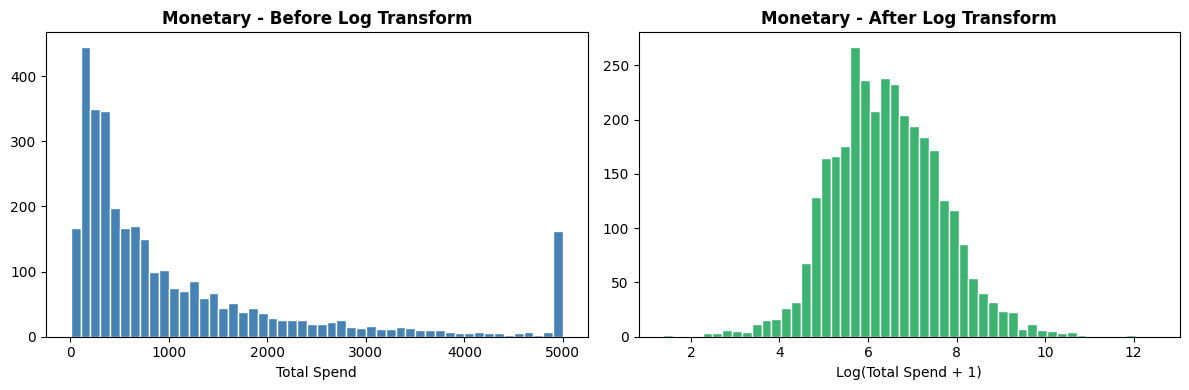

In [44]:
# Visualization of before and after for monetary feature

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(master["Monetary"].clip(upper=5000),
             bins=50,
             color="steelblue",
             edgecolor="white")
axes[0].set_title("Monetary - Before Log Transform", fontweight="bold")
axes[0].set_xlabel("Total Spend")

axes[1].hist(master["log_Monetary"],
             bins=50,
             color="mediumseagreen",
             edgecolor="white")
axes[1].set_title("Monetary - After Log Transform", fontweight="bold")
axes[1].set_xlabel("Log(Total Spend + 1)")

plt.tight_layout()
plt.show()

**Scale Features**

In [45]:
feature_cols = [
    "log_Recency",
    "log_Frequency",
    "log_Monetary",
    "log_avg_order_value",
    "log_avg_days_between_orders",
    "log_tenure_days",
    "log_return_rate",
    "log_unique_products",
    "log_unique_months_active",
    "log_last_month_revenue",
]

target_col = "log_ltv_3m"

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(master[feature_cols])

In [47]:
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue
0,0.104535,1.961654,-0.401244,-0.556017,1.547711,0.763191,3.168516,-0.118673,1.021149,-0.592977
1,0.543312,-0.250956,0.575466,0.422449,-0.463292,-0.245991,1.048683,0.400006,-0.066124,-0.592977
2,0.517621,-0.898103,-0.186402,0.198685,-0.874340,-0.512201,-0.433140,-0.263219,-0.929141,-0.592977
3,0.356033,-0.250956,0.808244,1.101121,1.421210,0.794288,-0.433140,0.115271,-0.066124,-0.592977
4,0.183956,0.855349,0.943777,0.258923,0.618359,0.809574,0.268733,0.893693,0.546197,-0.592977


In [48]:
X_scaled_df["Customer ID"] = master["Customer ID"].values
X_scaled_df["log_ltv_3m"] = master["log_ltv_3m"].values
X_scaled_df

,log_Recency,log_Frequency,log_Monetary,log_avg_order_value,log_avg_days_between_orders,log_tenure_days,log_return_rate,log_unique_products,log_unique_months_active,log_last_month_revenue,Customer ID,log_ltv_3m
0,0.104535,1.961654,-0.401244,-0.556017,1.547711,0.763191,3.168516,-0.118673,1.021149,-0.592977,12346,0.000000
1,0.543312,-0.250956,0.575466,0.422449,-0.463292,-0.245991,1.048683,0.400006,-0.066124,-0.592977,12349,7.246810
2,0.517621,-0.898103,-0.186402,0.198685,-0.874340,-0.512201,-0.433140,-0.263219,-0.929141,-0.592977,12355,0.000000
3,0.356033,-0.250956,0.808244,1.101121,1.421210,0.794288,-0.433140,0.115271,-0.066124,-0.592977,12358,6.929595
4,0.183956,0.855349,0.943777,0.258923,0.618359,0.809574,0.268733,0.893693,0.546197,-0.592977,12359,6.314146
...,...,...,...,...,...,...,...,...,...,...,...,...
3308,0.600511,-0.898103,-1.300407,-0.487116,-0.874340,-0.384723,-0.433140,-0.928150,-0.929141,-0.592977,18281,0.000000
3309,-1.379078,0.564353,-0.298777,-1.990499,0.068990,0.357022,-0.433140,1.277134,0.546197,1.115275,18283,5.279899
3310,1.091954,-0.898103,-0.293195,0.741037,-0.874340,0.371074,-0.433140,-0.777554,-0.929141,-0.592977,18285,0.000000
3311,-1.456194,-0.250956,0.592840,0.043154,1.063077,0.752665,0.244185,0.713998,-0.066124,1.942232,18286,0.000000


In [49]:
print("Scaled feature shape:", X_scaled_df.shape)

Scaled feature shape: (3313, 12)


**Save Outputs**

In [50]:
model_df = master[feature_cols + ["log_ltv_3m", "Customer ID"]].copy()
model_df.to_csv("features.csv", index=False)

X_scaled_df.to_csv("features_scaled.csv", index=False)

In [51]:
print(f"features.csv shape: {model_df.shape}")
print(f"features_scaled.csv: {X_scaled_df.shape}")

features.csv shape: (3313, 12)
features_scaled.csv: (3313, 12)


In [52]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']